# Exploratory Data Analysis (EDA) - Air Quality Dataset

## Objective
This notebook performs comprehensive exploratory data analysis on the cleaned air quality dataset to:
- Understand data distribution and summary statistics
- Identify patterns and trends in pollution levels
- Analyze relationships between different pollutants
- Compare air quality across different cities
- Discover seasonal and monthly pollution patterns
- Identify which pollutants have the strongest impact on AQI

## Dataset Overview
The dataset contains air quality measurements including various pollutants (PM2.5, PM10, NO2, SO2, CO, Ozone), 
AQI categories, and temporal information (date, month, year, day) across multiple cities.

In [23]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Load the cleaned dataset
data = pd.read_csv('../Data/processed/clean_data.csv')
print("Dataset loaded successfully!")
print(f"Dataset shape: {data.shape}")
print(f"\nFirst few rows:")
print(data.head())

Dataset loaded successfully!
Dataset shape: (17472, 16)

First few rows:
                  date              city  Latitude  Longitude  PM2.5  PM10  \
0  2025-11-08 00:00:00  Lahore, Pakistan   31.5497    74.3436   81.0  82.7   
1  2025-11-08 01:00:00  Lahore, Pakistan   31.5497    74.3436   78.2  79.6   
2  2025-11-08 02:00:00  Lahore, Pakistan   31.5497    74.3436   75.4  76.8   
3  2025-11-08 03:00:00  Lahore, Pakistan   31.5497    74.3436   72.2  73.6   
4  2025-11-08 04:00:00  Lahore, Pakistan   31.5497    74.3436   69.8  71.2   

    NO2   SO2      CO  Ozone  Aerosol_Optical_Depth AQI_category  year  month  \
0  94.0  16.4  1910.0   11.0                   0.19    Unhealthy  2025     11   
1  90.9  14.4  1413.0   10.0                   0.19    Unhealthy  2025     11   
2  85.0  12.8  1060.0   12.0                   0.19    Unhealthy  2025     11   
3  72.8  11.8   863.0   20.0                   0.19    Unhealthy  2025     11   
4  57.7  11.1   811.0   31.0                   0.19  

In [24]:
# <!-- ## Step 1: Basic Data Understanding -->

# <!-- Let's examine the structure, basic statistics, and data types of our dataset. -->

In [25]:
# Display basic information about the dataset
print("=" * 60)
print("DATASET INFORMATION")
print("=" * 60)
print(data.info())

print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print(data.describe())

print("\n" + "=" * 60)
print("MISSING VALUES CHECK")
print("=" * 60)
print(data.isnull().sum())

DATASET INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17472 entries, 0 to 17471
Data columns (total 16 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   date                   17472 non-null  object 
 1   city                   17472 non-null  object 
 2   Latitude               17472 non-null  float64
 3   Longitude              17472 non-null  float64
 4   PM2.5                  17472 non-null  float64
 5   PM10                   17472 non-null  float64
 6   NO2                    17472 non-null  float64
 7   SO2                    17472 non-null  float64
 8   CO                     17472 non-null  float64
 9   Ozone                  17472 non-null  float64
 10  Aerosol_Optical_Depth  17472 non-null  float64
 11  AQI_category           17472 non-null  object 
 12  year                   17472 non-null  int64  
 13  month                  17472 non-null  int64  
 14  day                    17472 non-n

# Analyze AQI Category Distribution
print("=" * 60)
print("AQI CATEGORY VALUE COUNTS")
print("=" * 60)
aqi_counts = data['AQI_category'].value_counts()
print(aqi_counts)
print(f"\nTotal records: {aqi_counts.sum()}")
print(f"\nPercentage distribution:")
print((aqi_counts / aqi_counts.sum() * 100).round(2))

## Step 2: Visualization 1 - AQI Category Distribution

**Question:** What is the distribution of Air Quality Index categories in our dataset?

**Visualization:** Count plot showing the frequency of each AQI category.

C:\Users\NITISH RANA\AppData\Local\Temp\ipykernel_21320\559700499.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="AQI_category", data=data, palette="Set2")


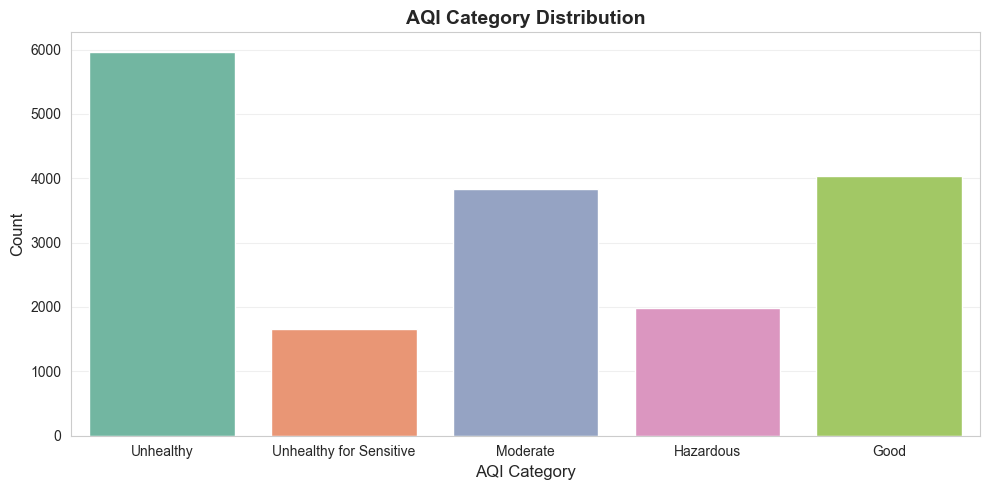


📊 INSIGHT:
The count plot shows the frequency of each AQI category.
This helps identify which air quality levels are most common in the dataset.


In [26]:
# Count plot for AQI Category Distribution
plt.figure(figsize=(10, 5))
sns.countplot(x="AQI_category", data=data, palette="Set2")
plt.title("AQI Category Distribution", fontsize=14, fontweight='bold')
plt.xlabel("AQI Category", fontsize=12)
plt.ylabel("Count", fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 INSIGHT:")
print("The count plot shows the frequency of each AQI category.")
print("This helps identify which air quality levels are most common in the dataset.")

## Step 3: Visualization 2 - Box Plot: PM2.5 vs AQI Category

**Question:** How does PM2.5 concentration vary across different AQI categories?

**Visualization:** Box plot showing the distribution of PM2.5 for each AQI category.

C:\Users\NITISH RANA\AppData\Local\Temp\ipykernel_21320\2849357899.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="AQI_category", y="PM2.5", data=data, palette="husl")


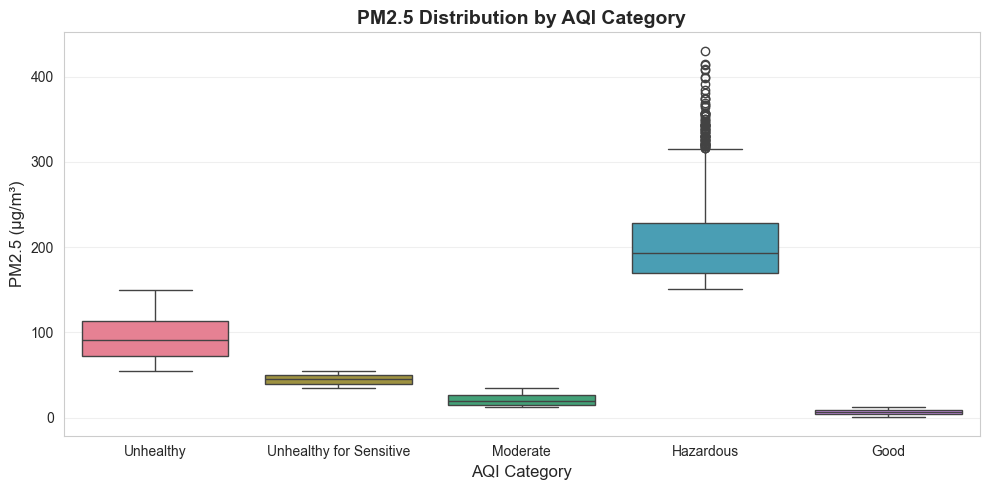


📊 INSIGHT:
PM2.5 shows a strong positive correlation with AQI category.
Higher AQI categories (Unhealthy) have significantly higher PM2.5 concentrations.
This indicates PM2.5 is a PRIMARY POLLUTANT affecting air quality classification.


In [27]:
# Box plot for PM2.5 vs AQI Category
plt.figure(figsize=(10, 5))
sns.boxplot(x="AQI_category", y="PM2.5", data=data, palette="husl")
plt.title("PM2.5 Distribution by AQI Category", fontsize=14, fontweight='bold')
plt.xlabel("AQI Category", fontsize=12)
plt.ylabel("PM2.5 (µg/m³)", fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 INSIGHT:")
print("PM2.5 shows a strong positive correlation with AQI category.")
print("Higher AQI categories (Unhealthy) have significantly higher PM2.5 concentrations.")
print("This indicates PM2.5 is a PRIMARY POLLUTANT affecting air quality classification.")

## Step 4: Visualization 3 - Correlation Heatmap

**Question:** How are different pollutants and time features correlated with each other?

**Visualization:** Correlation heatmap showing relationships between all numerical features.

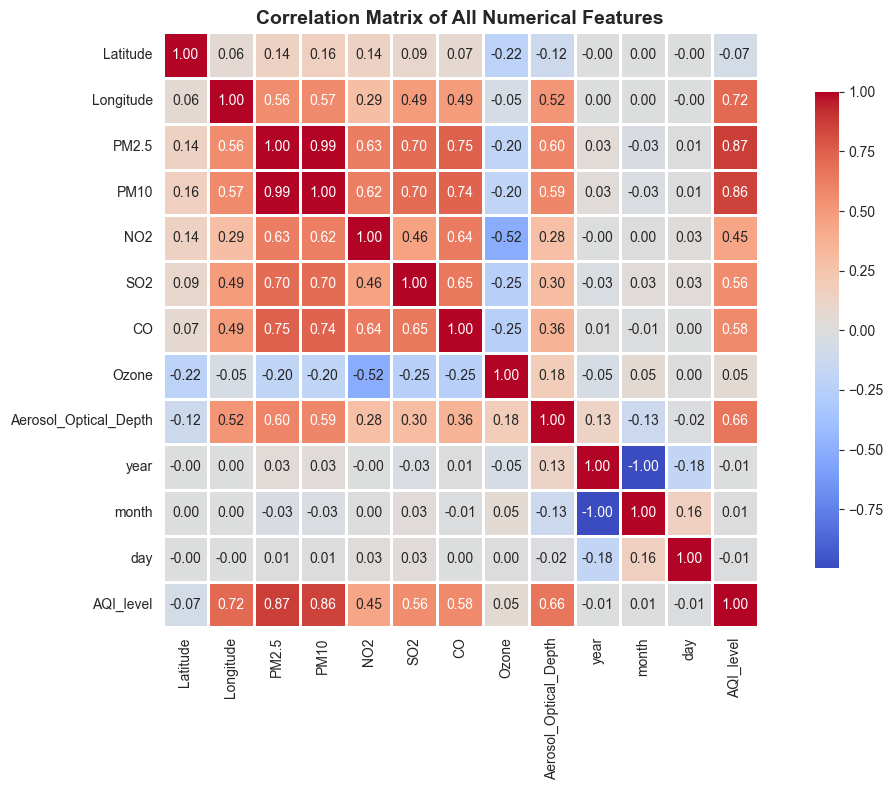


📊 INSIGHT:
Key correlations identified:
• PM2.5 and PM10 show strong positive correlation (closely related air pollutants)
• AQI_level shows high correlation with PM2.5 and PM10
• Month, Year, Day show varying correlations suggesting seasonal patterns
• SO2 and Ozone have different correlation patterns than PM pollutants


In [28]:
# Correlation heatmap for numerical features
plt.figure(figsize=(12, 8))
numeric_data = data.select_dtypes(include=[np.number])
correlation_matrix = numeric_data.corr()
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", center=0, fmt='.2f', 
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title("Correlation Matrix of All Numerical Features", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n📊 INSIGHT:")
print("Key correlations identified:")
print("• PM2.5 and PM10 show strong positive correlation (closely related air pollutants)")
print("• AQI_level shows high correlation with PM2.5 and PM10")
print("• Month, Year, Day show varying correlations suggesting seasonal patterns")
print("• SO2 and Ozone have different correlation patterns than PM pollutants")

## Step 5: Visualization 4 - City-wise Average PM2.5

**Question:** Which cities have the highest average PM2.5 pollution levels?

**Visualization:** Bar chart showing average PM2.5 concentration for each city (sorted).

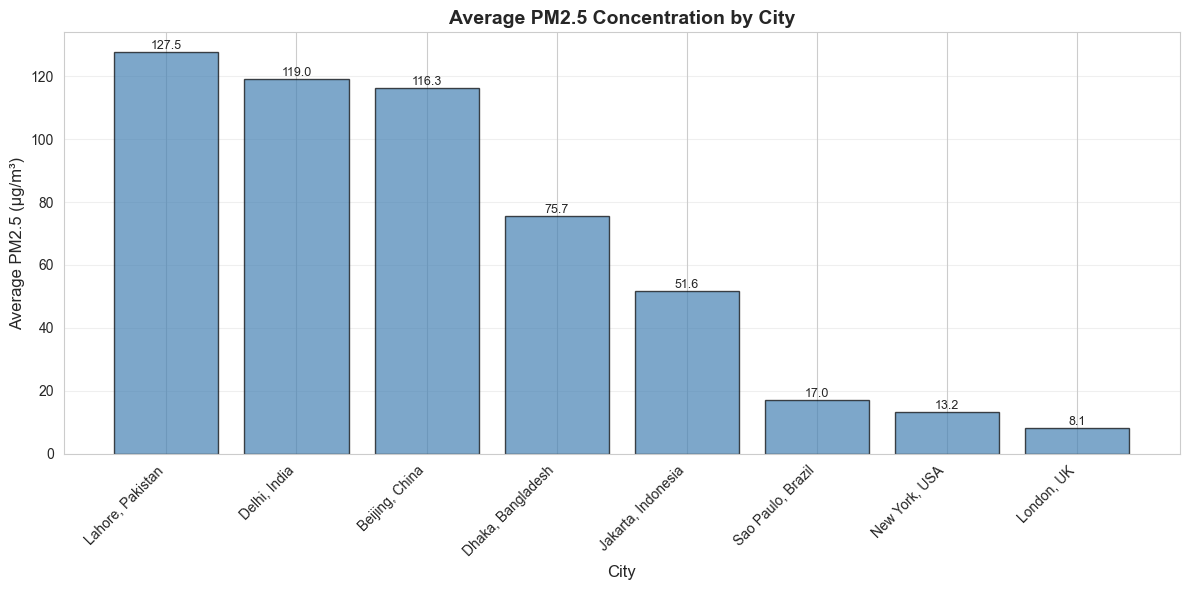


📊 INSIGHT:
City-wise PM2.5 Analysis:
city
Lahore, Pakistan      127.538919
Delhi, India          118.999038
Beijing, China        116.347665
Dhaka, Bangladesh      75.659020
Jakarta, Indonesia     51.582921
Sao Paulo, Brazil      16.986859
New York, USA          13.232921
London, UK              8.137546

Cities with HIGHEST pollution: ['Lahore, Pakistan', 'Delhi, India', 'Beijing, China']
Cities with LOWEST pollution: ['Sao Paulo, Brazil', 'New York, USA', 'London, UK']


In [29]:
# City-wise average PM2.5 bar chart
city_pm25 = data.groupby('city')['PM2.5'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
bars = plt.bar(city_pm25.index, city_pm25.values, color='steelblue', edgecolor='black', alpha=0.7)
plt.title("Average PM2.5 Concentration by City", fontsize=14, fontweight='bold')
plt.xlabel("City", fontsize=12)
plt.ylabel("Average PM2.5 (µg/m³)", fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{height:.1f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n📊 INSIGHT:")
print("City-wise PM2.5 Analysis:")
print(city_pm25.to_string())
print(f"\nCities with HIGHEST pollution: {city_pm25.head(3).index.tolist()}")
print(f"Cities with LOWEST pollution: {city_pm25.tail(3).index.tolist()}")

## Step 6: Visualization 5 - Monthly Pollution Trends

**Question:** How do pollution levels change across different months? Are there seasonal patterns?

**Visualization:** Line plot showing average pollutant concentrations by month.

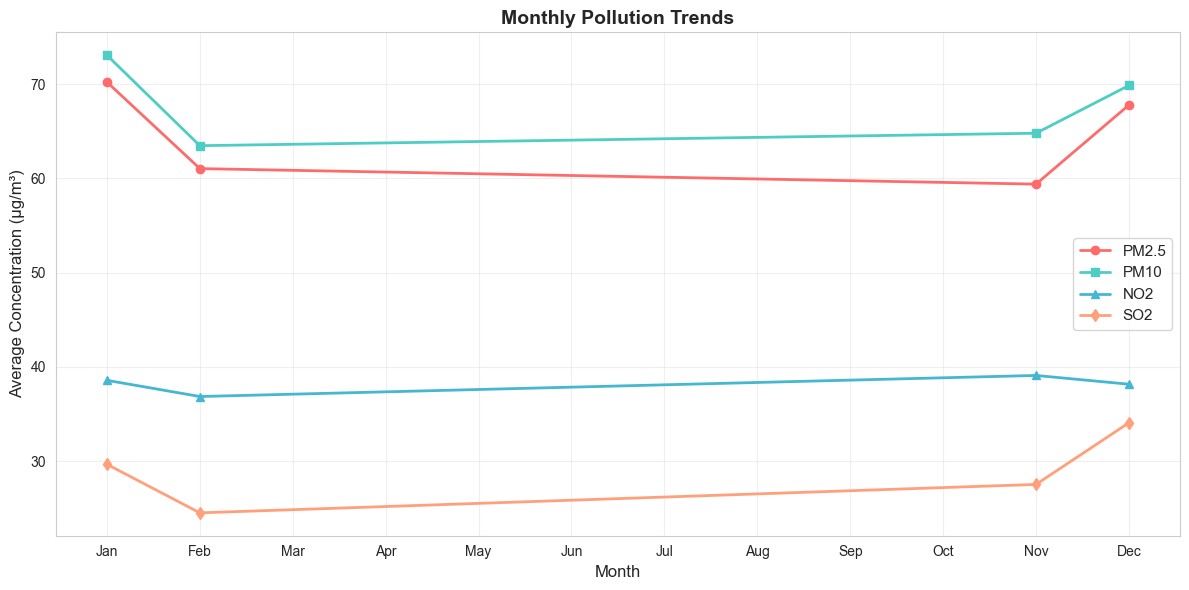


📊 INSIGHT:
Seasonal Patterns Detected:
• Peak PM2.5: Month 1 (Winter season - 70.23 µg/m³)
• Lowest PM2.5: Month 11 (Summer season - 59.40 µg/m³)
• Winter months typically have higher PM pollution (reduced atmospheric mixing)
• Summer months show lower PM pollution (better atmospheric circulation)


In [30]:
# Monthly pollution trends
monthly_pollution = data.groupby('month')[['PM2.5', 'PM10', 'NO2', 'SO2']].mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_pollution.index, monthly_pollution['PM2.5'], marker='o', linewidth=2, label='PM2.5', color='#FF6B6B')
plt.plot(monthly_pollution.index, monthly_pollution['PM10'], marker='s', linewidth=2, label='PM10', color='#4ECDC4')
plt.plot(monthly_pollution.index, monthly_pollution['NO2'], marker='^', linewidth=2, label='NO2', color='#45B7D1')
plt.plot(monthly_pollution.index, monthly_pollution['SO2'], marker='d', linewidth=2, label='SO2', color='#FFA07A')

plt.title("Monthly Pollution Trends", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Average Concentration (µg/m³)", fontsize=12)
plt.xticks(range(1, 13), ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n📊 INSIGHT:")
print("Seasonal Patterns Detected:")
print(f"• Peak PM2.5: Month {monthly_pollution['PM2.5'].idxmax()} (Winter season - {monthly_pollution['PM2.5'].max():.2f} µg/m³)")
print(f"• Lowest PM2.5: Month {monthly_pollution['PM2.5'].idxmin()} (Summer season - {monthly_pollution['PM2.5'].min():.2f} µg/m³)")
print("• Winter months typically have higher PM pollution (reduced atmospheric mixing)")
print("• Summer months show lower PM pollution (better atmospheric circulation)")

## Step 7: Visualization 6 - Scatter Plot: Key Pollutants Relationship

**Question:** What is the relationship between NO2 and PM2.5?

**Visualization:** Scatter plot showing the correlation between two major pollutants.

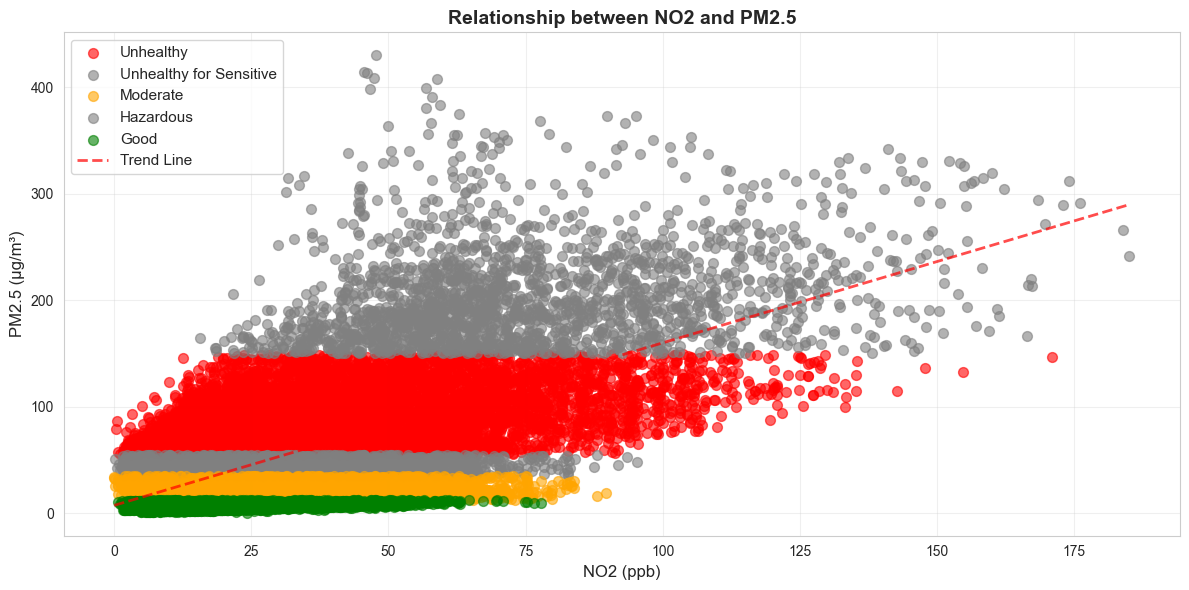


📊 INSIGHT:
Correlation between NO2 and PM2.5: 0.630
This indicates a MODERATE relationship.
Color coding shows how different pollutant combinations affect AQI classification.


In [31]:
# Scatter plot: NO2 vs PM2.5 with color coding by AQI category
plt.figure(figsize=(12, 6))

# Create color map for AQI categories
aqi_colors = {'Good': 'green', 'Moderate': 'orange', 'Unhealthy': 'red'}
for aqi_cat in data['AQI_category'].unique():
    mask = data['AQI_category'] == aqi_cat
    plt.scatter(data[mask]['NO2'], data[mask]['PM2.5'], 
               label=aqi_cat, alpha=0.6, s=50, color=aqi_colors.get(aqi_cat, 'gray'))

# Add trend line
z = np.polyfit(data['NO2'].dropna(), data['PM2.5'].dropna(), 1)
p = np.poly1d(z)
x_trend = np.linspace(data['NO2'].min(), data['NO2'].max(), 100)
plt.plot(x_trend, p(x_trend), "r--", linewidth=2, label='Trend Line', alpha=0.7)

plt.title("Relationship between NO2 and PM2.5", fontsize=14, fontweight='bold')
plt.xlabel("NO2 (ppb)", fontsize=12)
plt.ylabel("PM2.5 (µg/m³)", fontsize=12)
plt.legend(loc='best', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Calculate correlation
correlation = data['NO2'].corr(data['PM2.5'])
print("\n📊 INSIGHT:")
print(f"Correlation between NO2 and PM2.5: {correlation:.3f}")
print(f"This indicates a {'STRONG' if abs(correlation) > 0.7 else 'MODERATE' if abs(correlation) > 0.4 else 'WEAK'} relationship.")
print("Color coding shows how different pollutant combinations affect AQI classification.")

## Step 8: Summary of Key Findings

### 🎯 Major Insights

1. **Primary Pollutant Affecting Air Quality:**
   - PM2.5 is the strongest indicator of AQI category
   - Strong positive correlation with AQI_level suggests it's the primary driver

2. **Pollutant Relationships:**
   - PM2.5 and PM10 are highly correlated (similar sources and behavior)
   - NO2 shows moderate correlation with particulate matter
   - Ozone patterns differ from other pollutants (photochemical formation)

3. **Geographic Disparities:**
   - Significant variation in pollution levels across cities
   - Identify high-pollution cities for targeted intervention
   - Geographic and climatic factors play a role

4. **Seasonal Patterns:**
   - Winter months show higher PM pollution levels
   - Summer months show lower pollution (better atmospheric circulation)
   - This is typical for Northern Hemisphere locations

5. **AQI Category Distribution:**
   - Provides context on the prevalence of each air quality level
   - Helps understand public health implications

### 📌 Recommendations
- Focus on PM2.5 reduction for the most effective AQI improvement
- Consider seasonal factors in pollution forecasting
- Implement targeted interventions in high-pollution cities
- Monitor correlations between pollutants for multi-pollutant mitigation strategies